# Что нужно сделать

#### Цель практической работы
Вы провели А/В-тестирование старого и нового подходов к формированию стоимости полиса ВЗР. Первый подход включает в себя традиционную оценку рисков, а второй — использование результатов кластеризации. 

Основные влияющие факторы: цена полиса, конверсия в оформления и убыточность. 

В этой практической работе вам предстоит провести статистический анализ результатов теста и, основываясь на полученных данных, порекомендовать бизнесу новый или старый вариант ценообразования.

#### Что нужно сделать
1. Проведите расчёт A/B-теста в Jupyter Notebook и посчитайте значения основных метрик. Рекомендуем выбрать метрики на основе влияющих факторов, но финальное определение метрики за вами. 
Статистический тест можно использовать любой, но в этой задаче будет достаточно стандартного t-test.
2. После расчёта значений метрик сделайте бизнес-рекомендацию и обоснуйте, почему предлагаете такое решение (рассмотрите позитивное и негативное влияние на бизнес).


#### Советы и рекомендации
Используйте датасеты CONTRACTS и LOSSES из предыдущего датасета. 

Вам также потребуется датасет EXPERIMENT_GROUPS, содержащий записи о клиентах, которым была показана цена полиса и тестовая группа, в которую они попали (от которой зависела показанная цена).

Для удобства можно использовать курс доллара к рублю на уровне 80.

### Import library

In [26]:
import pandas as pd
import sqlite3
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import lightgbm as lgb
import optuna

from sklearn.preprocessing import OrdinalEncoder, StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_score, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, silhouette_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.manifold import TSNE


from scipy.stats import mannwhitneyu
from scipy.stats import shapiro
from scipy.cluster.hierarchy import dendrogram, linkage

from category_encoders import BinaryEncoder


pd.options.display.float_format = '{:.2f}'.format

### Import data

In [2]:
conn = sqlite3.connect('data/shop_database.db')

df_personal_data = pd.read_sql(
    "SELECT *"
    "FROM personal_data ",
    conn
)
df_personal_data_coeffs = pd.read_sql(
    "SELECT id, personal_coef "
    "FROM personal_data_coeffs",
    conn
)
df_purchases = pd.read_sql(
    "SELECT *"
    "FROM purchases",
    conn
)
df_loss_data = pd.read_csv('data/personal_data.csv')
df_loss_data.insert(1, 'gender', np.nan)

In [3]:
full_personal_data = pd.concat([df_personal_data, df_loss_data], ignore_index=True)
df_full = full_personal_data.merge(df_personal_data_coeffs, on='id', how='left').merge(df_purchases, on='id', how='right')
df_full = df_full[df_full['country'] == 32]
df_full.isna().sum()

id                    0
gender           115452
age                   0
education             0
city                  0
country               0
personal_coef         0
product               0
colour           119181
cost                  0
product_sex      312577
base_sale             0
dt                    0
dtype: int64

In [4]:
df_full.head(10)

,id,gender,age,education,city,country,personal_coef,product,colour,cost,product_sex,base_sale,dt
0,0,0.00,36,среднее,1201,32,0.51,"Велосипед горный женский Stern Mira 2.0 26""",белый/синий,13599,0.00,1,7
1,0,0.00,36,среднее,1201,32,0.51,Стол Outventure,зелёный,1499,NaN,0,37
2,0,0.00,36,среднее,1201,32,0.51,Набор Outventure: стол + 4 стула,бежевый,4799,NaN,0,37
3,3,NaN,31,среднее,1134,32,0.43,Бутсы мужские GSD Astro,белый,1599,1.00,0,13
4,3,NaN,31,среднее,1134,32,0.43,Мяч футбольный PUMA TEAMFINAL 21.2 FIFA QUALIT...,мультицвет,7199,NaN,0,27
5,3,NaN,31,среднее,1134,32,0.43,Кеды мужские FILA A-Low,белый,2799,1.00,1,34
6,3,NaN,31,среднее,1134,32,0.43,Полуботинки мужские Outventure Chase,серый,2999,1.00,0,34
7,4,0.00,35,среднее,1134,32,0.51,Роликовые коньки детские Roces Orlando III,черный/розовый,9199,NaN,0,0
8,4,0.00,35,среднее,1134,32,0.51,Шлем FILA NRK FUN,белый,4999,NaN,0,0
9,4,0.00,35,среднее,1134,32,0.51,Роликовые коньки детские Roces Yuma TIF,мультицвет,6999,NaN,0,1


### Processing voids

In [5]:
df_full.loc[df_full['colour'].str.count('/') == 1, 'colour'] = 'двухцветный'
df_full.loc[df_full['colour'].str.count('/') > 1, 'colour'] = 'мультицвет'
df_full['colour'] = df_full['colour'].fillna('другой')

df_full.loc[df_full['product'].str.contains('мальчиков|девочек', case=False), 'product_sex'] = 2
df_full['product_sex'] = df_full['product_sex'].fillna(3)

# Общая категория для цветов, которые встречаются меньше 1300 раз (<5% от всех данных)
color_counts = df_full['colour'].value_counts()
rare_values = color_counts[color_counts < 1300].index
df_full.loc[df_full['colour'].isin(rare_values), 'colour'] = 'редкий'

df_full = df_full[~(df_full['cost'] < 0)]
df_full = df_full[~(df_full['age'] < 16)]

df_full.isna().sum()

id                    0
gender           112546
age                   0
education             0
city                  0
country               0
personal_coef         0
product               0
colour                0
cost                  0
product_sex           0
base_sale             0
dt                    0
dtype: int64

### Binary classification

##### Model training

In [6]:
df_for_learn = df_full[~df_full['gender'].isna()]
df_for_learn = df_for_learn[df_for_learn.groupby('city')['city'].transform('count') > 1000] # Фильтр редких городов. Отфильтровано ~3% данных

df_for_classification = df_full[df_full['gender'].isna()]

In [7]:
X = df_for_learn.drop(['id', 'gender', 'country', 'personal_coef', 'dt'], axis=1)
y = df_for_learn['gender']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
)

In [8]:
education_levels = [['среднее', 'высшее']]

pipe = Pipeline([
    ('encoder', ColumnTransformer([
        ('ordinal', OrdinalEncoder(categories=education_levels), ['education']),
        ('binary', BinaryEncoder(), ['colour']),
        ('Tfid', TfidfVectorizer(max_features=100, min_df=5, max_df=0.95), 'product'),
    ], remainder='passthrough')),  
    ('scaler', StandardScaler(with_mean=False))
])

X_train_tr = pipe.fit_transform(X_train)
X_test_tr = pipe.transform(X_test)

In [9]:
lg = LogisticRegression(
    C=10,
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)

lg.fit(X_train_tr, y_train)
y_pred_train_lg = lg.predict(X_train_tr)
y_pred_test_lg = lg.predict(X_test_tr)

In [10]:
print(f'Точность на обучении: \n' 
      f'F1-score: {f1_score(y_pred_train_lg, y_train)}\n'
      f'Precision:  {precision_score(y_pred_train_lg, y_train)}\n'
      f'Recall: {recall_score(y_pred_train_lg, y_train)}\n'
      f'Accuracy: {accuracy_score(y_pred_train_lg, y_train)}\n'
) 
print(f'Точность на тесте: \n'
      f'F1-score: {f1_score(y_pred_test_lg, y_test)}\n'
      f'Accuracy: {accuracy_score(y_pred_test_lg, y_test)}'
)

Точность на обучении: 
F1-score: 0.7833792280588805
Precision:  0.8114948694621543
Recall: 0.7571465771167497
Accuracy: 0.7520212610425842

Точность на тесте: 
F1-score: 0.7843821374024409
Accuracy: 0.7534567011135144


In [11]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=25,        
    min_samples_leaf=5, 
    max_features='sqrt', 
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train_tr, y_train)
y_pred_train_rf = rf.predict(X_train_tr)
y_pred_test_rf = rf.predict(X_test_tr)

In [12]:
print(f'Точность на обучении: \n' 
      f'F1-score: {f1_score(y_pred_train_rf, y_train)}\n'
      f'Precision:  {precision_score(y_pred_train_rf, y_train)}\n'
      f'Recall: {recall_score(y_pred_train_rf, y_train)}\n'
      f'Accuracy: {accuracy_score(y_pred_train_rf, y_train)}\n'
) 
print(f'Точность на тесте: \n'
      f'F1-score: {f1_score(y_pred_test_rf, y_test)}\n'
      f'Accuracy: {accuracy_score(y_pred_test_rf, y_test)}'
)

Точность на обучении: 
F1-score: 0.8042101153055091
Precision:  0.8510422367767682
Recall: 0.7622634159010486
Accuracy: 0.7710332313940843

Точность на тесте: 
F1-score: 0.7982971488897876
Accuracy: 0.7642954418008492


In [13]:
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    max_iter=100,           
    batch_size=512,         
    early_stopping=True,    
    random_state=42
)

mlp.fit(X_train_tr, y_train)
y_pred_train_mlp = mlp.predict(X_train_tr)
y_pred_test_mlp = mlp.predict(X_test_tr)

In [14]:
print(f'Точность на обучении: \n' 
      f'F1-score: {f1_score(y_pred_train_mlp, y_train)}\n'
      f'Precision:  {precision_score(y_pred_train_mlp, y_train)}\n'
      f'Recall: {recall_score(y_pred_train_mlp, y_train)}\n'
      f'Accuracy: {accuracy_score(y_pred_train_mlp, y_train)}\n'
) 
print(f'Точность на тесте: \n'
      f'F1-score: {f1_score(y_pred_test_mlp, y_test)}\n'
      f'Accuracy: {accuracy_score(y_pred_test_mlp, y_test)}\n'
)

Точность на обучении: 
F1-score: 0.7994801298996569
Precision:  0.8539346205286755
Recall: 0.7515543206765323
Accuracy: 0.7633126851278846

Точность на тесте: 
F1-score: 0.7976811830587723
Accuracy: 0.7615156612993671



##### Filling nan

In [15]:
features = df_for_classification.drop(['id', 'gender', 'country', 'personal_coef', 'dt'], axis=1)

features_tr = pipe.transform(features)
gender_pred = rf.predict(features_tr)

df_for_classification.loc[:, 'gender'] = gender_pred
df_for_classification.head()

,id,gender,age,education,city,country,personal_coef,product,colour,cost,product_sex,base_sale,dt
3,3,1.00,31,среднее,1134,32,0.43,Бутсы мужские GSD Astro,белый,1599,1.00,0,13
4,3,1.00,31,среднее,1134,32,0.43,Мяч футбольный PUMA TEAMFINAL 21.2 FIFA QUALIT...,мультицвет,7199,3.00,0,27
5,3,1.00,31,среднее,1134,32,0.43,Кеды мужские FILA A-Low,белый,2799,1.00,1,34
6,3,1.00,31,среднее,1134,32,0.43,Полуботинки мужские Outventure Chase,серый,2999,1.00,0,34
128,33,1.00,34,среднее,1167,32,0.43,Футболка мужская Kappa Authentic Icon,черный,1699,1.00,0,4


In [27]:
df_processed = pd.concat([df_for_learn, df_for_classification], ignore_index=True)
df_processed.head(10)

,id,gender,age,education,city,country,personal_coef,product,colour,cost,product_sex,base_sale,dt
0,0,0.00,36,среднее,1201,32,0.51,"Велосипед горный женский Stern Mira 2.0 26""",двухцветный,13599,0.00,1,7
1,0,0.00,36,среднее,1201,32,0.51,Стол Outventure,зелёный,1499,3.00,0,37
2,0,0.00,36,среднее,1201,32,0.51,Набор Outventure: стол + 4 стула,бежевый,4799,3.00,0,37
3,4,0.00,35,среднее,1134,32,0.51,Роликовые коньки детские Roces Orlando III,двухцветный,9199,3.00,0,0
4,4,0.00,35,среднее,1134,32,0.51,Шлем FILA NRK FUN,белый,4999,3.00,0,0
5,4,0.00,35,среднее,1134,32,0.51,Роликовые коньки детские Roces Yuma TIF,мультицвет,6999,3.00,0,1
6,4,0.00,35,среднее,1134,32,0.51,Набор защиты из 3-х предметов детский Reaction...,двухцветный,999,3.00,0,1
7,4,0.00,35,среднее,1134,32,0.51,Шлем для девочек Reaction Urban,розовый,1499,2.00,0,2
8,4,0.00,35,среднее,1134,32,0.51,Роликовые коньки детские раздвижные Reaction R...,двухцветный,4399,3.00,0,2
9,4,0.00,35,среднее,1134,32,0.51,Куртка утепленная для девочек Outventure,другой,2999,2.00,0,32


### A/B test analysis 

##### First company

H0: Предоставление персональной скидки не влияет на доход с пользователя и количество покупок, которые он совершает

H1: Предоставление персональной скидки значительно (>10%) повышает доход с пользователя или количество покупок, которые он совершнает

In [29]:
with open('data/ids_first_company_positive.txt', 'r', encoding='utf-8') as file:
    ids_p = file.read()

ids_p_list = re.findall(r'\d+', ids_p)
ids_positive = [int(x) for x in ids_p_list]

with open('data/ids_first_company_negative.txt', 'r', encoding='utf-8') as file:
    ids_n = file.read()

ids_n_list = re.findall(r'\d+', ids_n)
ids_negative = [int(x) for x in ids_n_list]

In [30]:
df_positive = df_processed[df_processed['id'].isin(ids_positive)]
df_positive = df_positive[(df_positive['dt'] >= 5) & (df_positive['dt'] <=16)]

df_negative = df_processed[df_processed['id'].isin(ids_negative)]
df_negative = df_negative[(df_negative['dt'] >= 5) & (df_negative['dt'] <=16)]

positive_grouped = df_positive.groupby(['id']).agg(
    total_revenue = ('cost', 'sum'),
    quantity_goods = ('cost', 'count'),
    avg_goods_price = ('cost', 'mean')
).reset_index()

negative_grouped = df_negative.groupby(['id']).agg(
    total_revenue = ('cost', 'sum'),
    quantity_goods = ('cost', 'count'),
    avg_goods_price = ('cost', 'mean')
).reset_index()

In [31]:
positive_costs = positive_grouped['total_revenue']
negative_costs = negative_grouped['total_revenue']
stat_pos, p_pos = shapiro(positive_costs)
stat_neg, p_neg = shapiro(negative_costs)

positive_avg_income = round(np.average(positive_costs), 2)
positive_median_income = round(np.median(positive_costs), 2)
positive_avg_product_price = round(positive_grouped['avg_goods_price'].mean(), 2)
positive_median_product_price = round(np.median(positive_grouped['avg_goods_price']), 2)
positive_avg_purchases_count = round(positive_grouped['quantity_goods'].mean(), 2)
positive_median_purchases_count = round(np.median(positive_grouped['quantity_goods']), 2)

negative_avg_income = round(np.average(negative_costs), 2)
negative_median_income = round(np.median(negative_costs), 2)
negative_avg_product_price = round(negative_grouped['avg_goods_price'].mean(), 2)
negative_median_product_price = round(np.median(negative_grouped['avg_goods_price']), 2)
negative_avg_purchases_count = round(negative_grouped['quantity_goods'].mean(), 2)
negative_median_purchases_count = round(np.median(negative_grouped['quantity_goods']), 2)


if p_pos > 0.05:
    print('Тестовая группа имеет нормальное распределение')
else:
    print('Тестовая группа не имеет нормального распределения')

if p_neg > 0.05:
    print('Контрольная группа имеет нормальное распределение\n')
else:
    print('Контрольная группа не имеет нормального распределения\n')

print(f'POSITIVE\n'\
      f'Доход с пользователя, AVG: {positive_avg_income}, MEDIAN: {positive_median_income}\n'\
      f'Цена товара из всех покупок пользователя, AVG: {positive_avg_product_price}, MEDIAN: {positive_median_product_price}\n'\
      f'Число покупок, AVG: {positive_avg_purchases_count}, MEDIAN: {positive_median_purchases_count}\n'\
)

print(f'NEGATIVE\n'\
      f'Доход с пользователя, AVG: {negative_avg_income}, MEDIAN: {negative_median_income}\n'\
      f'Цена товара из всех покупок пользователя, AVG: {negative_avg_product_price}, MEDIAN: {negative_median_product_price}\n'\
      f'Число покупок, AVG: {negative_avg_purchases_count}, MEDIAN: {negative_median_purchases_count}\n'\
)


Тестовая группа не имеет нормального распределения
Контрольная группа не имеет нормального распределения

POSITIVE
Доход с пользователя, AVG: 27617.8, MEDIAN: 15497.0
Цена товара из всех покупок пользователя, AVG: 5741.09, MEDIAN: 3899.0
Число покупок, AVG: 5.22, MEDIAN: 4.0

NEGATIVE
Доход с пользователя, AVG: 22451.49, MEDIAN: 11028.0
Цена товара из всех покупок пользователя, AVG: 6153.78, MEDIAN: 3914.5
Число покупок, AVG: 4.01, MEDIAN: 2.0



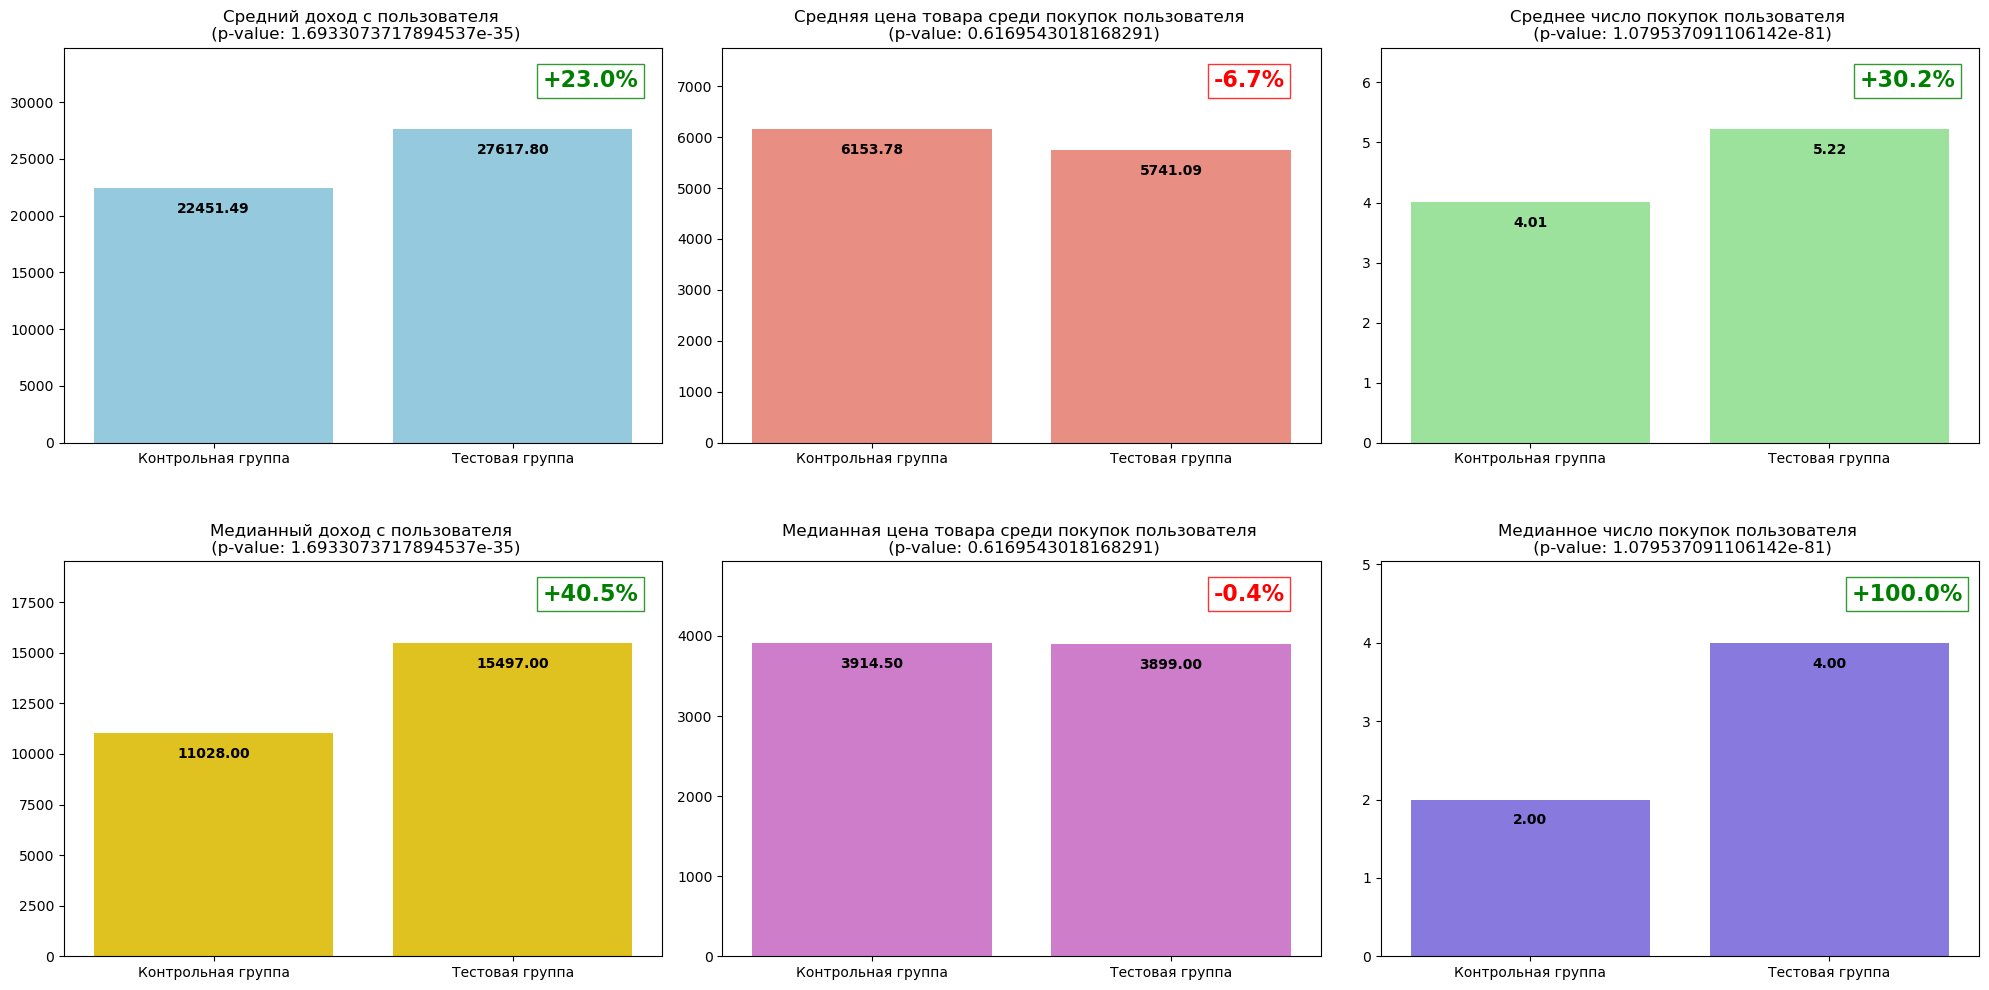

In [36]:
def calc_pvalue(positive, negative):
    stat, p = mannwhitneyu(positive, negative)
    return p

colors = ['skyblue', 'salmon', 'lightgreen', 'gold', 'orchid', 'mediumslateblue']
groups = ['Контрольная группа', 'Тестовая группа']

figure, axes = plt.subplots(nrows=2, ncols=3, figsize=(20,10))

sns.barplot(
    x=groups, 
    hue=groups, 
    y=[negative_avg_income, positive_avg_income], 
    ax=axes[0, 0], 
    palette=[colors[0], colors[0]])
axes[0, 0].set_title(f'Средний доход с пользователя \n (p-value: {calc_pvalue(positive_costs, negative_costs)})')

sns.barplot(
    x=groups, 
    hue=groups, 
    y=[negative_avg_product_price, positive_avg_product_price], 
    ax=axes[0, 1], 
    palette=[colors[1], colors[1]])
axes[0, 1].set_title(f'Средняя цена товара среди покупок пользователя \n (p-value: {calc_pvalue(positive_grouped['avg_goods_price'], negative_grouped['avg_goods_price'])})')

sns.barplot(
    x=groups, 
    hue=groups, 
    y=[negative_avg_purchases_count, positive_avg_purchases_count], 
    ax=axes[0, 2], 
    palette=[colors[2], colors[2]])
axes[0, 2].set_title(f'Среднее число покупок пользователя \n (p-value: {calc_pvalue(positive_grouped['quantity_goods'], negative_grouped['quantity_goods'])})')

sns.barplot(
    x=groups, 
    hue=groups, 
    y=[negative_median_income, positive_median_income], 
    ax=axes[1, 0], 
    palette=[colors[3], colors[3]])
axes[1, 0].set_title(f'Медианный доход с пользователя \n (p-value: {calc_pvalue(positive_costs, negative_costs)})')

sns.barplot(
    x=groups, 
    hue=groups, 
    y=[negative_median_product_price, positive_median_product_price], 
    ax=axes[1, 1], 
    palette=[colors[4], colors[4]])
axes[1, 1].set_title(f'Медианная цена товара среди покупок пользователя \n (p-value: {calc_pvalue(positive_grouped['avg_goods_price'], negative_grouped['avg_goods_price'])})')

sns.barplot(
    x=groups, 
    hue=groups, 
    y=[negative_median_purchases_count, positive_median_purchases_count], 
    ax=axes[1, 2], 
    palette=[colors[5], colors[5]])
axes[1, 2].set_title(f'Медианное число покупок пользователя \n (p-value: {calc_pvalue(positive_grouped['quantity_goods'], negative_grouped['quantity_goods'])})')

for ax in axes.flat:
    y_min, y_max = ax.get_ylim()
    ax.set_ylim(y_min, y_max * 1.2)

for ax in axes.flat:
    if len(ax.containers) >= 2:
        val_test = ax.containers[1][0].get_height()
        val_control = ax.containers[0][0].get_height()
        
        if val_control != 0:
            diff = (val_test / val_control - 1) * 100
            color = 'green' if diff >= 0 else 'red'
            
            ax.text(0.88, 0.9, f"{diff:+.1f}%", 
                    transform=ax.transAxes, 
                    ha='center', fontsize=16, fontweight='bold', 
                    color=color, bbox=dict(facecolor='white', alpha=0.8, edgecolor=color))

    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=-20, fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(hspace=0.3) 
plt.show()

По результатам А/В теста можно наблюдать рост следующих показателей у тестовой группы: средний и медианный доход с пользователя, среднее и медианное число покупок

Средняя и медианная цена товара среди покупок пользователя немного упала, но этот результат не является статистически значимым и, скорее всего, вызван случайными колебаниями 

Из этого можно сделать вывод, что во время проведения первой РК пользователи стали покупать больше товаров и приносить больше прибыли, а следовательно, H1 принимается

##### Second company

Н0: Банерная реклама на билбордах не стимулирует пользователей совершать покупки чаще, или покупать более дорогостоящие товары

Н1: Банерная реклама на билбордах стимулирует повышает доход в день акции более чем на 10%

In [37]:
second_comp_grouped = df_processed.groupby(['dt']).agg(
    revenue=('cost', 'sum'),
    orders=('id', 'count'),
    unique_users=('id', 'nunique')
).reset_index()

second_comp_grouped['day_type'] = second_comp_grouped['dt'].apply(lambda x: 'День акции' if x == 15 or x == 45 else 'Обычный день')

second_comp_grouped.head()

,dt,revenue,orders,unique_users,day_type
0,0,112697709,18754,12126,Обычный день
1,1,103428370,17521,10844,Обычный день
2,2,95625028,16950,10433,Обычный день
3,3,97358003,17380,10639,Обычный день
4,4,97056758,17602,10727,Обычный день


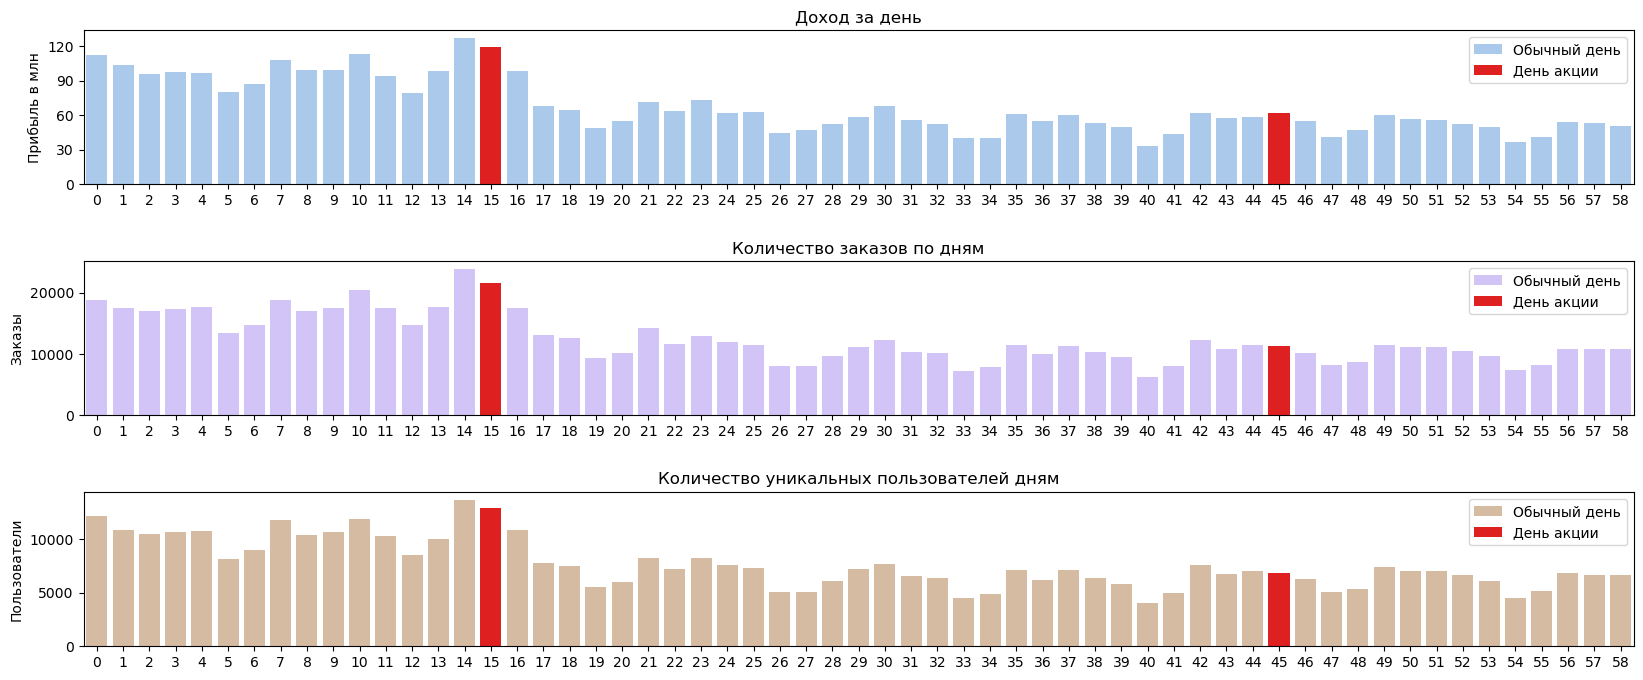

In [38]:
figure, axes = plt.subplots(nrows=3, ncols=1, figsize=(20, 8))

sns.barplot(
    data=second_comp_grouped,
    x=second_comp_grouped['dt'], 
    y=second_comp_grouped['revenue'], 
    ax=axes[0], 
    palette={'День акции': 'red', 'Обычный день': '#a1c9f4'},
    hue='day_type'
)
axes[0].set_title('Доход за день')
axes[0].legend(title='') 
axes[0].set_ylabel('Прибыль в млн')
axes[0].set_xlabel('')

axes[0].ticklabel_format(style='plain', axis='y')
axes[0].yaxis.set_major_locator(ticker.MultipleLocator(30_000_000))
axes[0].get_yaxis().set_major_formatter(
    ticker.FuncFormatter(lambda x, p: f'{int(x/1_000_000)}')
)

sns.barplot(
    data=second_comp_grouped,
    x=second_comp_grouped['dt'], 
    y=second_comp_grouped['orders'], 
    ax=axes[1], 
    palette={'День акции': 'red', 'Обычный день': '#d0bbff'},
    hue='day_type'
)
axes[1].set_title('Количество заказов по дням')
axes[1].legend(title='') 
axes[1].set_ylabel('Заказы')
axes[1].set_xlabel('')

sns.barplot(
    data=second_comp_grouped,
    x=second_comp_grouped['dt'], 
    y=second_comp_grouped['unique_users'], 
    ax=axes[2], 
    palette={'День акции': 'red', 'Обычный день': '#debb9b'},
    hue='day_type'
)
axes[2].set_title('Количество уникальных пользователей дням')
axes[2].legend(title='') 
axes[2].set_ylabel('Пользователи')
axes[2].set_xlabel('')

plt.subplots_adjust(hspace=0.5) 
plt.show()

На графике можно увидеть, что с 0 по 16 день доход колеблется в промежутке между 80 и 120 млн, а после 16 дня упал до промежутка 40-70 млн 

Самым прибыльным днем оказался 14.

15 акционный день при этом является вторым по уровню прибыли за все время рекламной компании, но не выделяется на промежутке 0 - 16 дней

45 акционных день не выделается на промежутке 17-58 дней

Из этого можно сделать вывод, что 15 акционный день, скорее всего, случайно стал вторым по уровню прибыли, а в рекламная компания незначительно повлияла на уроень дохода, количество заказов и уникальных пользователей
Также стоит отметить, что для адекватного анализа данных слишком мало: акционных дней всего 2 и нет никаких данных о промежутке с 0 по 16 день, из-за чего невозможно объяснить повышенный спрос в этот период

Н0 Принимается
 

### Clustering

In [22]:
df_for_clustering = df_processed.copy()
df_for_clustering = df_for_clustering.drop(['city', 'country', 'product', 'colour', 'dt'], axis=1)
df_for_clustering

,id,gender,age,education,personal_coef,cost,product_sex,base_sale
0,0,0.00,36,среднее,0.51,13599,0.00,1
1,0,0.00,36,среднее,0.51,1499,3.00,0
2,0,0.00,36,среднее,0.51,4799,3.00,0
3,4,0.00,35,среднее,0.51,9199,3.00,0
4,4,0.00,35,среднее,0.51,4999,3.00,0
...,...,...,...,...,...,...,...,...
736688,177984,0.00,43,среднее,0.51,2099,0.00,1
736689,177984,0.00,43,среднее,0.51,3499,0.00,1
736690,178002,1.00,50,среднее,0.43,5999,1.00,0
736691,178002,1.00,50,среднее,0.43,3499,1.00,0


In [23]:
df_for_clustering_grouped = df_for_clustering.groupby('id').agg(
    gender = ('gender', 'first'),
    age = ('age', 'first'),
    education = ('education', 'first'),
    personal_coef = ('personal_coef', 'first'),
    cost_mean = ('cost', 'mean'),
    cost_sum = ('cost', 'sum'),
    product_sex_0=('product_sex', lambda x: (x == 0).sum()),
    product_sex_1=('product_sex', lambda x: (x == 1).sum()),
    product_sex_2=('product_sex', lambda x: (x == 2).sum()),
    product_sex_3=('product_sex', lambda x: (x == 3).sum()),
    base_sale = ('base_sale', lambda x: x.mode().iloc[0] if not x.mode().empty else None),
).reset_index()

In [24]:
df_for_clustering_grouped['education'] = df_for_clustering_grouped['education'].map({'среднее': 0, 'высшее': 1})
df_for_clustering_grouped['cost_mean_log'] = np.log1p(df_for_clustering_grouped['cost_mean'])
df_for_clustering_grouped['cost_sum_log'] = np.log1p(df_for_clustering_grouped['cost_sum'])
df_for_clustering_grouped.head()

,id,gender,age,education,personal_coef,cost_mean,cost_sum,product_sex_0,product_sex_1,product_sex_2,product_sex_3,base_sale,cost_mean_log,cost_sum_log
0,0,0.00,36,0,0.51,6632.33,19897,1,0,0,2,0,8.80,9.90
1,3,1.00,31,0,0.43,3649.00,14596,0,3,0,1,0,8.20,9.59
2,4,0.00,35,0,0.51,4441.86,31093,0,0,2,5,0,8.40,10.34
3,6,1.00,52,0,0.43,5605.67,84085,0,9,4,2,0,8.63,11.34
4,7,0.00,37,0,0.51,4525.15,58827,5,0,5,3,0,8.42,10.98


In [26]:
features_clustering = df_for_clustering_grouped.drop(['id', 'cost_mean',  'cost_sum', 'personal_coef'], axis=1)
scaled_array_for_clustering = MinMaxScaler().fit_transform(features_clustering)
df_for_clustering_grouped_scaled = pd.DataFrame(scaled_array_for_clustering, columns=features_clustering.columns, index=features_clustering.index) #

sample_ids = np.random.choice(len(scaled_array_for_clustering), size=20000, replace=False)
data_sample = scaled_array_for_clustering[sample_ids]
tsne_array = TSNE(n_components=2).fit_transform(data_sample)

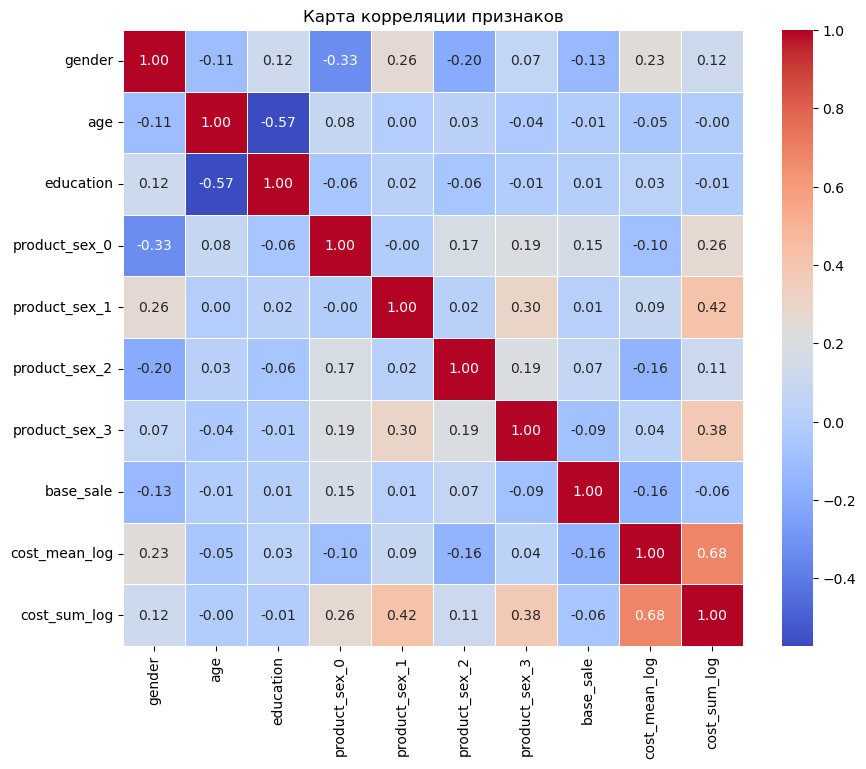

In [27]:
corr_matrix = features_clustering.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True,
            cmap='coolwarm', 
            fmt=".2f",
            linewidths=0.5)
plt.title('Карта корреляции признаков')
plt.show()

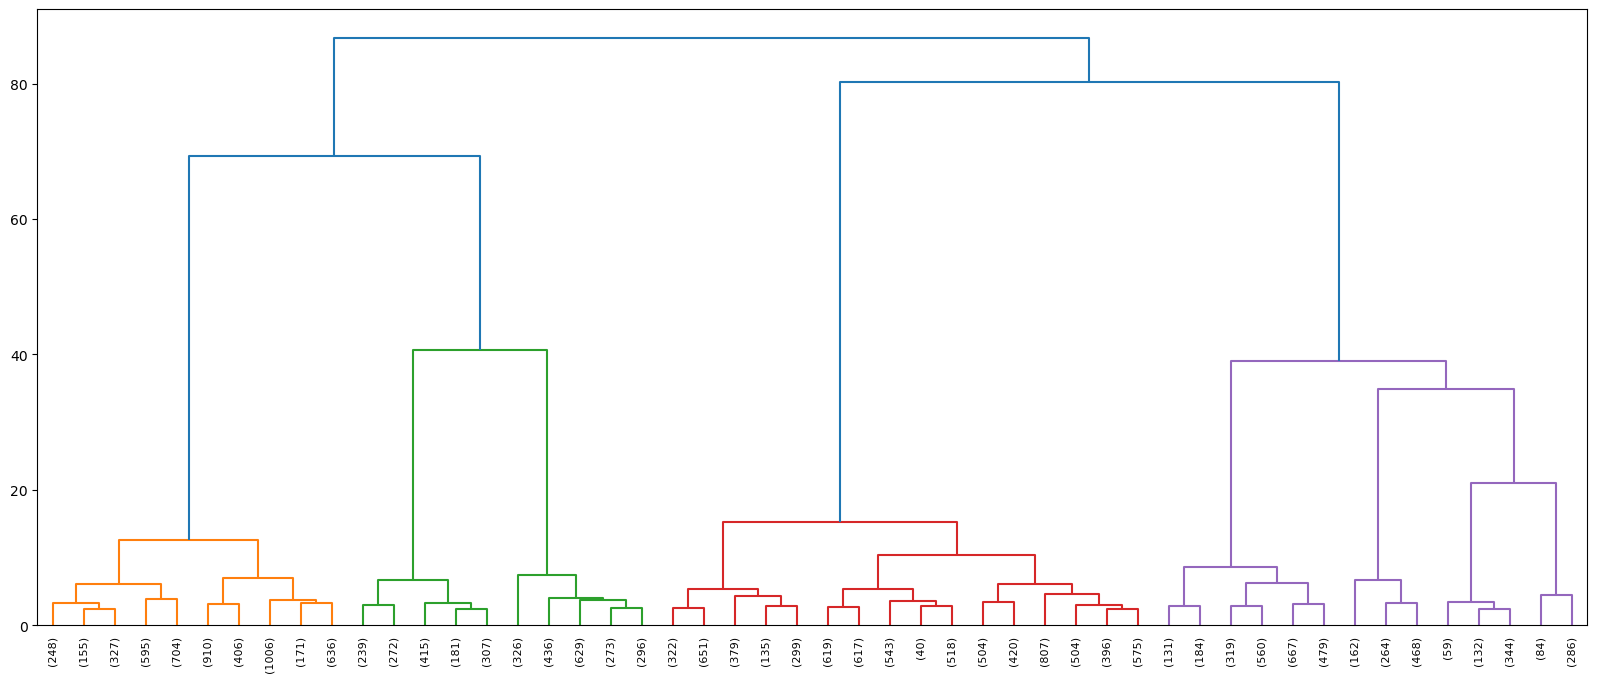

In [28]:
linked = linkage(data_sample, method='ward')
plt.figure(figsize=(20, 8))
dendrogram(
    linked,
    truncate_mode='lastp',
    p=50,
    show_leaf_counts=True)
plt.show()

In [159]:
inertia = []
silhouette = []

for i in range(2, 15):
    kmeans = KMeans(n_clusters=i, random_state=42).fit(data_sample)
    preds = kmeans.predict(data_sample)
    inertia.append(np.sqrt(kmeans.inertia_))
    silhouette.append(silhouette_score(data_sample, preds))

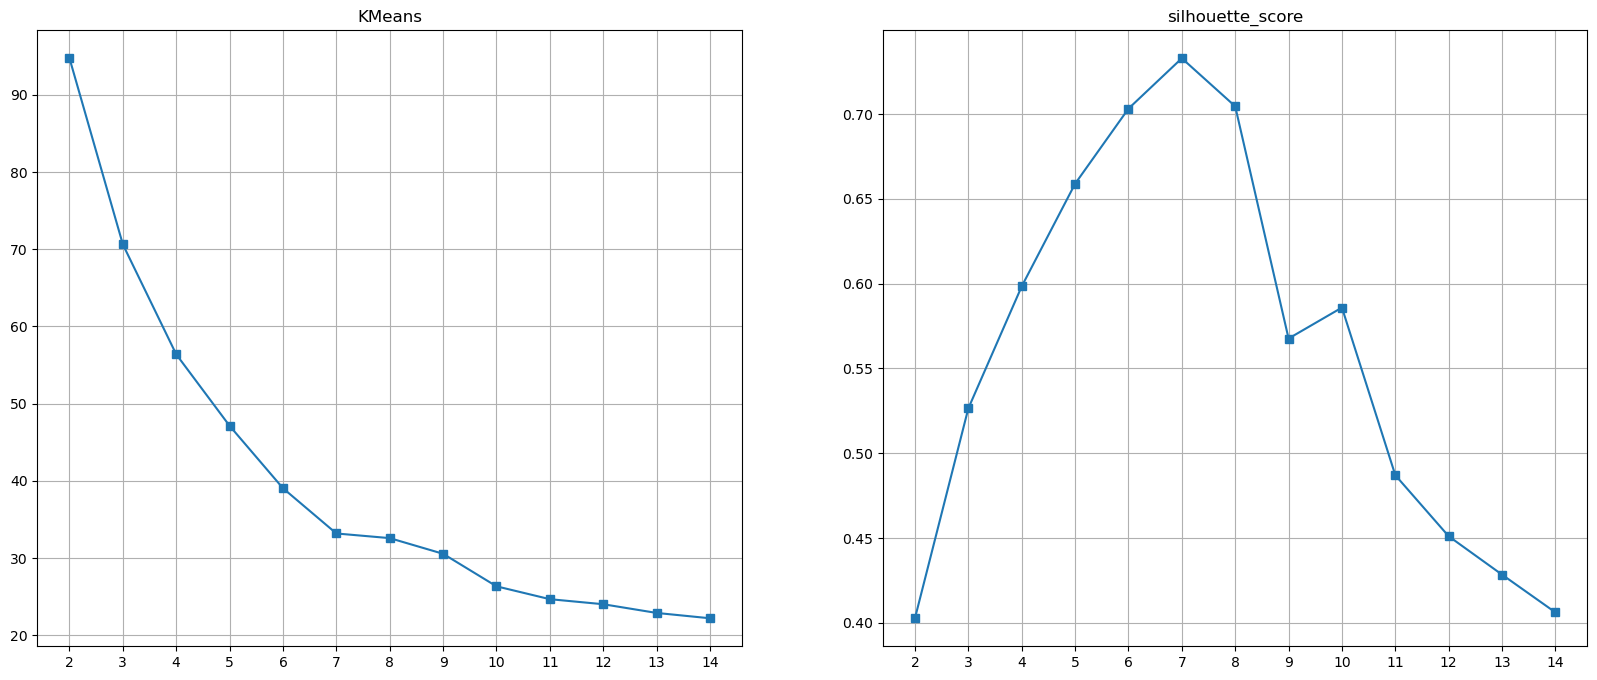

In [160]:
figure, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))
axes[0].plot(np.arange(2, 15), inertia, marker='s')
axes[0].grid(True)
axes[0].set_xticks(np.arange(2, 15))
axes[0].set_title('KMeans')

axes[1].plot(np.arange(2, 15), silhouette, marker='s')
axes[1].grid(True)
axes[1].set_xticks(np.arange(2, 15))
axes[1].set_title('silhouette_score')

plt.show()

In [30]:
agg_clst_8 = AgglomerativeClustering(compute_distances=True, n_clusters=8).fit(data_sample)

Судя по графикам оптимальное количесвто кластеров = 7, но в этом случае молодые мужчины и женщины с высшим образованием объединяются в один кластер, при этом мужчины предпочитают товары со скидкой, а женщины без. Объединение этих групп клиентов в один кластер может негативно сказаться на таргетировании, поэтому в качестве оптимального количества кластеров было выбрано второе по величине значение silhouette_score - 8

Пример разделения на 7 кластеров

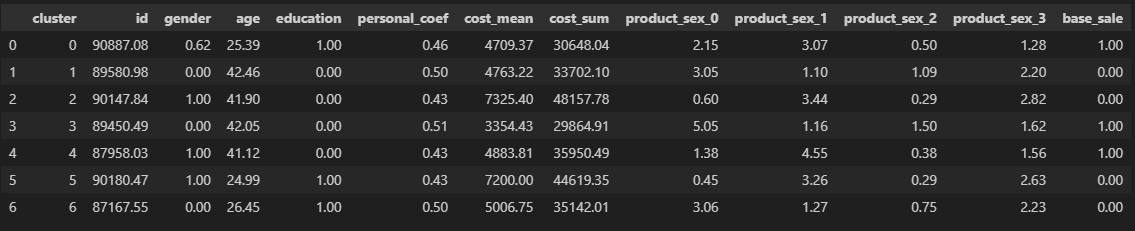

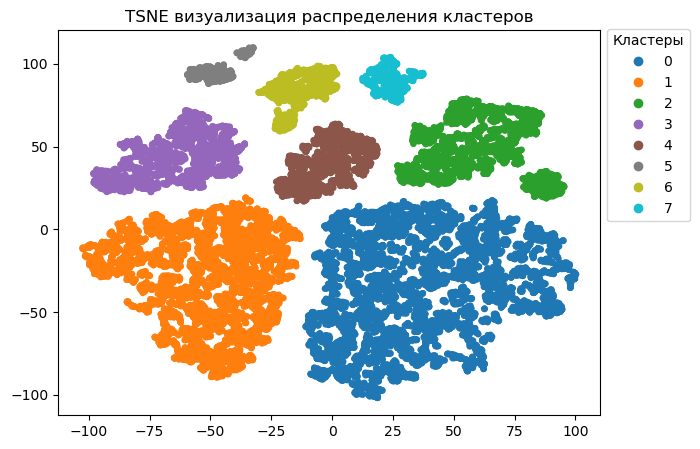

In [31]:
plt.figure(figsize=(7, 5))
scatter = plt.scatter(tsne_array[:, 0], tsne_array[:, 1], s=15, c=agg_clst_8.labels_, cmap='tab10')
plt.title('TSNE визуализация распределения кластеров')
plt.legend(*scatter.legend_elements(), title="Кластеры", bbox_to_anchor=(1, 1.022), loc='upper left')

plt.show()

In [32]:
df_sample = df_for_clustering_grouped.iloc[sample_ids].copy()
df_sample['cluster'] = agg_clst_8.labels_
df_sample = df_sample.drop(['cost_mean_log', 'cost_sum_log'], axis=1)

cluster_profile = df_sample.groupby('cluster').mean().reset_index()
cluster_sizes = df_sample['cluster'].value_counts(normalize=True).reset_index()
cluster_sizes.columns = ['cluster', 'share']
cluster_profile = cluster_profile.merge(cluster_sizes, on='cluster')

cluster_profile

,cluster,id,gender,age,education,personal_coef,cost_mean,cost_sum,product_sex_0,product_sex_1,product_sex_2,product_sex_3,base_sale,share
0,0,88530.43,1.00,41.92,0.00,0.43,7286.17,47834.27,0.61,3.46,0.29,2.85,0.00,0.37
1,1,87593.72,0.00,42.54,0.00,0.50,4593.87,32600.03,3.12,1.10,1.14,2.12,0.00,0.26
2,2,88540.98,1.00,24.82,1.00,0.43,7310.67,45964.24,0.53,3.25,0.26,2.58,0.00,0.12
3,3,88225.69,0.00,42.58,0.00,0.51,3390.67,29619.88,5.02,1.23,1.48,1.59,1.00,0.10
4,4,87889.16,1.00,41.48,0.00,0.43,4848.68,37371.09,1.23,4.72,0.49,1.75,1.00,0.07
5,5,90159.75,0.00,27.45,1.00,0.52,3852.48,28526.27,4.53,1.34,0.85,1.30,1.00,0.02
6,6,89682.05,0.00,26.63,1.00,0.51,5141.29,30939.10,2.79,1.12,0.61,1.95,0.00,0.04
7,7,89524.87,1.00,23.92,1.00,0.43,5080.37,31780.54,0.74,4.10,0.37,1.40,1.00,0.03


| Переменная | Код | Описание |
| :--- | :---: | :--- |
| **GENDER** | 0 | женщины |
| | 1 | мужчины |
| **PRODUCT_SEX** | 0 | женский |
| | 1 | мужской |
| | 2 | детский |
| | 3 | унисекс |
| **EDUCATION** | 0 | среднее |
| | 1 | высшее |



Кластер 0 - Самый крупный кластер. Мужчины среднего возраста, с средним образованием, с высокими расходами на покупки. В основном покупают товары категорий для мужчин и унисекс, остальными категориями интересуются мало. Скидка мало влияет на вероятность покупки. Методы работы с кластером: подойдут предложения с дорогими/премиальными товарами известных брендов, с акцентом на качество и статусность

Кластер 1 - Второй по величине кластер. Женщины среднего возраста, с средним образованием, с средними расходами на покупки. В основном покупают товары категорий для женщин и унисекс, умеренно интересуются остальными категориями. Скидка мало влияет на вероятность покупки. Методы работы с кластером: подойдут предложения среднего ценового сегмента, с акцентом на цена=качество

** Кластер 2 - Третий по величине кластер. Молодые мужчины, с высшим образованием, с высокими расходами на покупки. В основном покупают товары категорий для мужчин и унисекс, остальными категориями интересуются мало. Скидка мало влияет на вероятность покупки. Методы работы с кластером: подойдут предложения с дорогими/премиальными товарами известных брендов, с акцентом на качество и статусность

Кластер 3 - Четвертый по величине кластер. Женщины среднего возраста, с средним образованием, с низкими расходами на покупки. В основном покупают товары категорий для женщин, все остальные категории имеют умеренный спрос. Предпочитают товары по скидке. Методы работы с кластером: подойдут предложения с товарами низкой/средней ценовой категорией, в качестве мотивации к покупке стоит использовать скидку

Кластер 4 - Пятый по величине кластер. Мужчины среднего возраста, с средним образованием, с средними расходами на покупки. В основном покупают товары категорий для мужчин, мало интересуются товарами для детей и умеренно интересуются товарами для женщин и унисекс. Предпочитают товары по скидке. Методы работы с кластером: подойдут предложения среднего ценового сегмента, с акцентом на цена=качество, в качестве мотивации к покупке стоит использовать скидку

Кластер 5 - Малочисленный кластер. Молодые женщины, с высшим образованием, с низкими расходами на покупки. В основном покупают товары категорий для женщин, мало интересуются товарами для детей и умеренно интересуются товарами для мужчин и унисекс. Предпочитают товары по скидке. Методы работы с кластером: подойдут предложения с товарами низкой/средней ценовой категорией, в качестве мотивации к покупке стоит использовать скидку

Кластер 6 - Малочисленный кластер. Молодые женщины, с высшим образованием, с средними расходами на покупки. В основном покупают товары категорий для женщин и унисекс, мало интересуются товарами для детей и умеренно интересуются товарами для мужчин. Скидка мало влияет на вероятность покупки. Методы работы с кластером: подойдут предложения среднего ценового сегмента, с акцентом на цена=качество

Кластер 7 - Малочисленный кластер. Молодые мужчины, с высшим образованием, с средними расходами на покупки. В основном покупают товары категорий для мужчин и умеренно интересуются товарами категории унисекс. Остальными категориями интересуются мало. Предпочитают товары по скидке. Методы работы с кластером: подойдут предложения среднего ценового сегмента, с акцентом на цена=качество, в качестве мотивации к покупке стоит использовать скидку
_____________________________________
Основной акцент стоит сделать на 0-3 кластерах, так как они составляют большую долю покупателей. Остальные кластеры отлично подойдут для дополнительного подробного анализа и построения гипотез, которые позволят увеличить их численность/доход с покупятеля

** Имеет небольшое различие с КЛАСТЕРОМ 0: возраст и образование. Возможно, будет уместно объединить эти кластеры, если отличающиеся переменные не влияют на качество формирования индвидуального коммерческого предложения

### Customer propensity to purchase model

In [17]:
df_city_1188 = df_processed[df_processed['city'] == 1188].drop(['country', 'city'], axis=1).copy()

age_bins = [0, 18, 25, 35, 45, 100]
age_labels = ['До 18', '18-25', '26-35', '36-45', '45+']
df_city_1188['age_group'] = pd.cut(df_city_1188['age'], bins=age_bins, labels=age_labels, right=True)
df_city_1188['product_type'] = df_city_1188['product'].str.split().str[0]
df_city_1188['product_brand'] = df_city_1188['product'].str.replace(r'[а-яА-ЯёЁ.,]+', '', regex=True).str.strip().str.replace(r'\s+', ' ', regex=True)
df_city_1188 = df_city_1188.drop(['product', 'age'], axis=1)

print(f'Записей для города 1188: {df_city_1188.shape[0]}\n'
      f'Уникальных клиентов: {df_city_1188['id'].nunique()}')

Записей для города 1188: 87104
Уникальных клиентов: 12162


In [39]:
T = int(np.percentile(df_city_1188['dt'], 80)) # Временной сплит по 80-ому процентилю

df_before = df_city_1188[df_city_1188['dt'] <= T].copy()
df_after  = df_city_1188[df_city_1188['dt']  > T].copy()

buyers_before = df_before['id'].unique()          # клиенты, купившие до Т
buyers_after  = set(df_after['id'].unique())       # клиенты, купившие после T

target_df = pd.DataFrame({'id': buyers_before})
target_df['target'] = target_df['id'].apply(lambda x: 1 if x in buyers_after else 0)

def build_user_features(df_hist: pd.DataFrame) -> pd.DataFrame:
    grp = df_hist.groupby('id')

    profile = grp.agg(
        gender = ('gender', 'first'),
        personal_coef = ('personal_coef', 'first'),
        age_group = ('age_group', 'first'),
        education = ('education', 'first'),
    ).reset_index()

    behavior = grp.agg(
        n_transactions = ('dt', 'count'),
        n_unique_days = ('dt', 'nunique'),
        last_day = ('dt', 'max'),
        first_day  = ('dt', 'min'),
        total_spent = ('cost', 'sum'),
        avg_cost = ('cost', 'mean'),
        max_cost = ('cost', 'max'),
        min_cost = ('cost', 'min'),
        std_cost = ('cost', 'std'),
        n_with_discount = ('base_sale', 'sum'),
        avg_sale_day = ('base_sale', 'mean'),
        n_unique_types = ('product_type', 'nunique'),
        n_unique_brands = ('product_brand', 'nunique'),
        n_unique_colors = ('colour', 'nunique'),
        avg_product_sex = ('product_sex', 'mean'),
    ).reset_index()

    behavior['days_since_last'] = T - behavior['last_day'] # сколько дней до T клиент последний раз покупал
    behavior['active_span'] = behavior['last_day'] - behavior['first_day'] # активный период
    behavior['avg_inter_purchase'] = behavior.apply( # cредний интервал между покупками
        lambda r: r['active_span'] / (r['n_transactions'] - 1)
        if r['n_transactions'] > 1 else np.nan, axis=1
    )
    behavior['discount_rate'] = behavior['n_with_discount'] / behavior['n_transactions'] # доля транзакций со скидкой

    mode_type  = grp['product_type'].agg(lambda x: x.mode()[0]).reset_index().rename(columns={'product_type': 'top_product_type'}) # самый частый тип товара
    mode_brand = grp['product_brand'].agg(lambda x: x.mode()[0]).reset_index().rename(columns={'product_brand': 'top_product_brand'}) # самый частый бренд

    features = profile.merge(behavior, on='id').merge(mode_type,  on='id').merge(mode_brand, on='id')

    return features


features_df = build_user_features(df_before) # признаки
model_df = target_df.merge(features_df, on='id') # итоговый датафрейм для обучения

cat_cols = ['gender', 'age_group', 'education', 'top_product_type', 'top_product_brand']

model_df[cat_cols] = model_df[cat_cols].astype('category')

X = model_df.drop(['id', 'target'], axis=1).copy()
y = model_df['target']

print(f'Распределение классов:\n'
      f'{y.value_counts()}\n')

scale_pos = (y == 0).sum() / (y == 1).sum()

lgbm_model = lgb.LGBMClassifier(
    n_estimators=400, 
    learning_rate=0.015143640011880653, 
    max_depth=3, 
    num_leaves=130, 
    min_child_samples=41,
    subsample=0.7385612655437176,
    colsample_bytree=0.7142688015341878, 
    reg_alpha=1.6032150860255212e-07, 
    reg_lambda=0.6775021782493894,
    scale_pos_weight=scale_pos,
    random_state=42,
    n_jobs=-1,
    verbose=-1    
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # модель кросс валижации

cv_results = cross_validate(
    lgbm_model, X, y,
    cv = cv,
    scoring = ['roc_auc', 'average_precision'],
    n_jobs = -1,
)

print(f'Результаты кросс валидации:\n'
      f'ROC-AUC: {cv_results['test_roc_auc'].mean()}\n'
      f'PR-AUC {cv_results['test_average_precision'].mean()}\n')


oof_scores = cross_val_predict(
    lgbm_model, X, y,
    cv=cv,
    method='predict_proba',
    n_jobs=-1
)[:, 1]

model_df['propensity_score'] = oof_scores

top_clients = model_df[['id', 'propensity_score']].sort_values("propensity_score", ascending=False)
top_clients.tail(10)

Распределение классов:
target
0    6277
1    5649
Name: count, dtype: int64

Результаты кросс валидации:
ROC-AUC: 0.6409169964652668
PR-AUC 0.6139589980578923



,id,propensity_score
8722,153705,0.20
3361,59014,0.20
8366,147228,0.19
7783,137128,0.19
814,14487,0.19
7604,134059,0.19
10205,10184,0.18
31,455,0.18
2706,47609,0.18
1715,30706,0.16


In [19]:
# подбор гиперпараметров для модели

def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 600, step=50),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        
        'scale_pos_weight': scale_pos,
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }

    model = lgb.LGBMClassifier(**param)

    scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    
    return scores.mean()

study = optuna.create_study(direction='maximize', study_name='LGBM_Propensity')

study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f'Лучший ROC-AUC на CV: {study.best_value}')
print(f'Лучшие параметры: \n{study.best_params}')

best_params = study.best_params

final_params = {
    **best_params,
    'scale_pos_weight': scale_pos,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}

lgbm_model_best = lgb.LGBMClassifier(**final_params)

lgbm_model_best.fit(X, y)

model_df['propensity_score'] = lgbm_model_best.predict_proba(X)[:, 1]

top_clients = model_df[['id', 'propensity_score', 'target']].sort_values("propensity_score", ascending=False)
top_clients.head()

[I 2026-04-20 11:09:52,253] A new study created in memory with name: LGBM_Propensity


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-04-20 11:09:56,428] Trial 0 finished with value: 0.6256257068254275 and parameters: {'n_estimators': 450, 'learning_rate': 0.05782335471254596, 'max_depth': 7, 'num_leaves': 106, 'min_child_samples': 97, 'subsample': 0.5440150720245525, 'colsample_bytree': 0.6547054012935705, 'reg_alpha': 0.2558928627035563, 'reg_lambda': 3.714243807096988e-06}. Best is trial 0 with value: 0.6256257068254275.
[I 2026-04-20 11:09:59,521] Trial 1 finished with value: 0.6490647040077693 and parameters: {'n_estimators': 500, 'learning_rate': 0.010633510574677454, 'max_depth': 3, 'num_leaves': 72, 'min_child_samples': 93, 'subsample': 0.5888693089932886, 'colsample_bytree': 0.8931001134467564, 'reg_alpha': 0.007859981010168902, 'reg_lambda': 0.00048219187486310517}. Best is trial 1 with value: 0.6490647040077693.
[I 2026-04-20 11:10:01,043] Trial 2 finished with value: 0.627654312092616 and parameters: {'n_estimators': 400, 'learning_rate': 0.061832382398237476, 'max_depth': 6, 'num_leaves': 33, 'mi

,id,propensity_score,target
7662,134906,0.91,1
5805,102806,0.91,1
3480,61193,0.91,1
2621,46035,0.91,1
6983,123540,0.90,1
